# Data

## Dataset Overview

In [1]:
library(ggplot2)
library(tidyr)
library(dplyr)
library(rstatix)
library(pwr)
library(coin)
library(HDInterval)
source("config.R")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter


Loading required package: survival


Attaching package: ‘coin’


The following objects are masked from ‘package:rstatix’:

    chisq_test, friedman_test, kruskal_test, sign_test, wilcox_test




In [2]:
marketing.data <- read.csv(MARKETING_DATA)

str(marketing.data)

'data.frame':	588101 obs. of  7 variables:
 $ X            : int  0 1 2 3 4 5 6 7 8 9 ...
 $ user.id      : int  1069124 1119715 1144181 1435133 1015700 1137664 1116205 1496843 1448851 1446284 ...
 $ test.group   : chr  "ad" "ad" "ad" "ad" ...
 $ converted    : chr  "False" "False" "False" "False" ...
 $ total.ads    : int  130 93 21 355 276 734 264 17 21 142 ...
 $ most.ads.day : chr  "Monday" "Tuesday" "Tuesday" "Tuesday" ...
 $ most.ads.hour: int  20 22 18 10 14 10 13 18 19 14 ...


In [3]:
marketing.data$converted <- as.logical(toupper(marketing.data$converted))

day.levels <- c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday")
marketing.data$most.ads.day <- factor(marketing.data$most.ads.day, levels = day.levels, ordered = TRUE)

marketing.data$test.group <- factor(marketing.data$test.group, levels = c("psa", "ad"))

summary(marketing.data)

       X             user.id        test.group   converted      
 Min.   :     0   Min.   : 900000   psa: 23524   Mode :logical  
 1st Qu.:147025   1st Qu.:1143190   ad :564577   FALSE:573258   
 Median :294050   Median :1313725                TRUE :14843    
 Mean   :294050   Mean   :1310692                               
 3rd Qu.:441075   3rd Qu.:1484088                               
 Max.   :588100   Max.   :1654483                               
                                                                
   total.ads          most.ads.day   most.ads.hour  
 Min.   :   1.00   Monday   :87073   Min.   : 0.00  
 1st Qu.:   4.00   Tuesday  :77479   1st Qu.:11.00  
 Median :  13.00   Wednesday:80908   Median :14.00  
 Mean   :  24.82   Thursday :82982   Mean   :14.47  
 3rd Qu.:  27.00   Friday   :92608   3rd Qu.:18.00  
 Max.   :2065.00   Saturday :81660   Max.   :23.00  
                   Sunday   :85391                  

In [4]:
missing.idx <- which(!complete.cases(marketing.data))
length(missing.idx)

[1] 0

# Exploratory Data Analysis

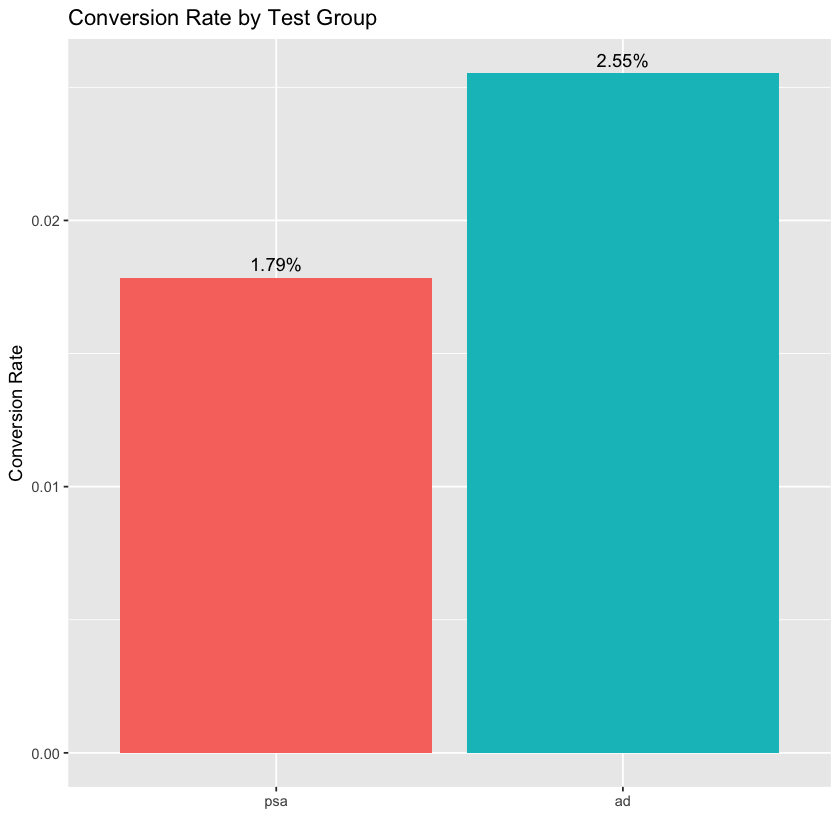

In [5]:
marketing.data %>%
  group_by(test.group) %>%
  summarise(converted_rate = mean(converted), .groups = "drop") %>%
  ggplot(aes(x = test.group, y = converted_rate, fill = test.group)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = scales::percent(converted_rate, accuracy = 0.01)),
            vjust = -0.5) +
  labs(title = "Conversion Rate by Test Group",
       x = "", y = "Conversion Rate") +
  theme(legend.position = "none")


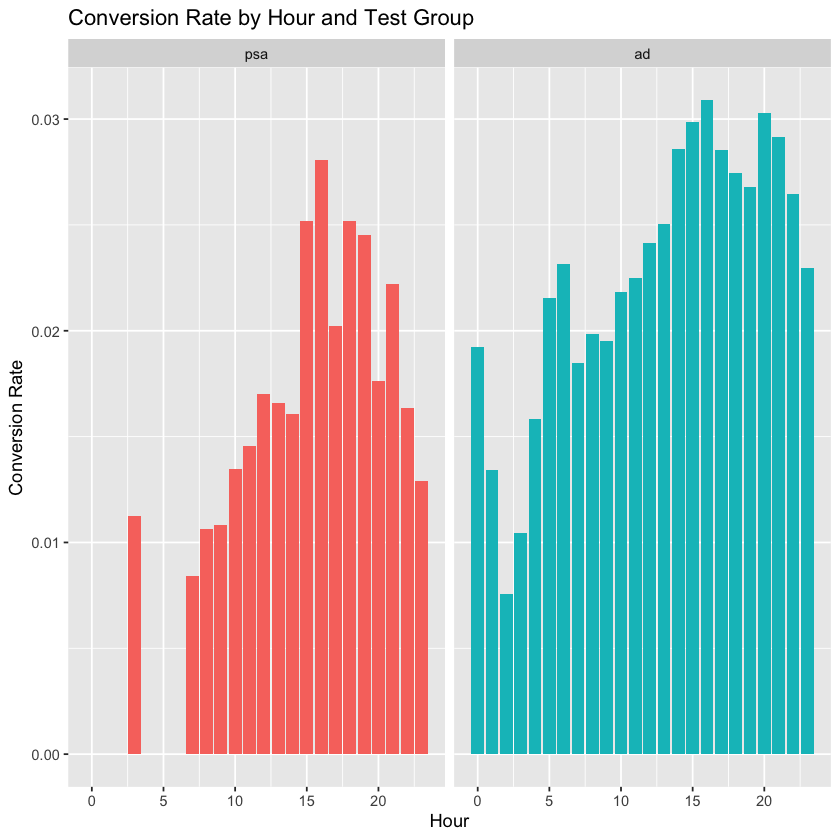

In [6]:
marketing.data %>%
  group_by(test.group, most.ads.hour) %>%
  summarise(converted_rate = mean(converted), .groups = "drop") %>%
  ggplot(aes(x = most.ads.hour, y = converted_rate, fill = test.group)) +
  geom_bar(stat = "identity") +
  facet_wrap(~ test.group) +
  labs(title = "Conversion Rate by Hour and Test Group", x = "Hour", y = "Conversion Rate") +
  theme(legend.position = "none")

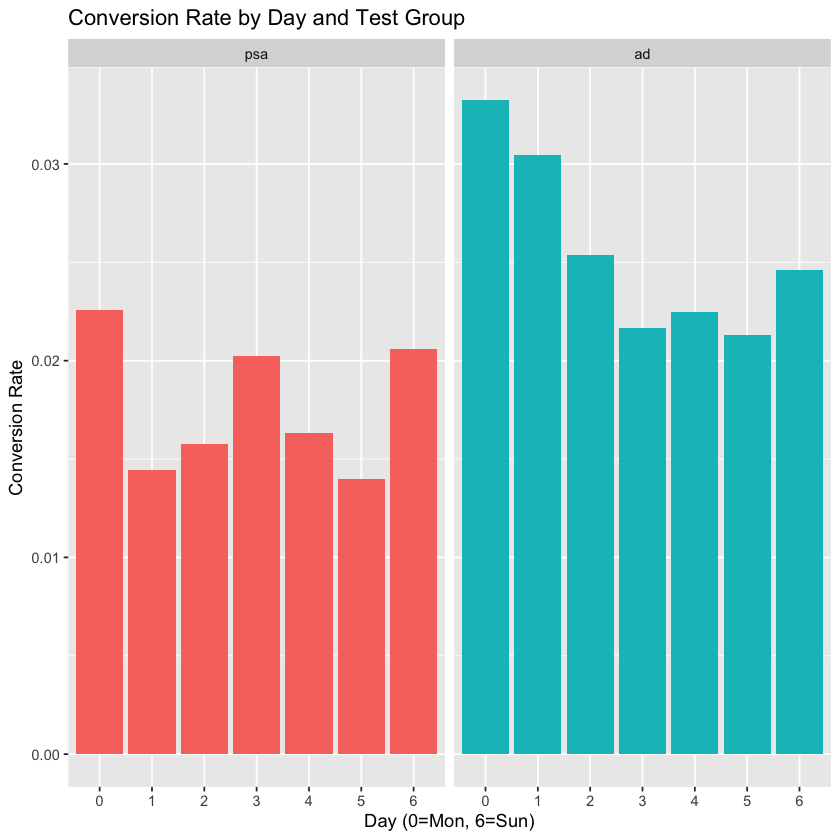

In [7]:
marketing.data %>%
  group_by(test.group, most.ads.day) %>%
  summarise(converted_rate = mean(converted), .groups = "drop") %>%
  ggplot(aes(x = most.ads.day, y = converted_rate, fill = test.group)) +
  geom_bar(stat = "identity") +
  facet_wrap(~ test.group) +
  scale_x_discrete(labels = 0:6) +
  labs(title = "Conversion Rate by Day and Test Group", x = "Day (0=Mon, 6=Sun)", y = "Conversion Rate") +
  theme(legend.position = "none")

In [ ]:
marketing.data %>%
  filter(test.group == "ad") %>%
  group_by(most.ads.day, most.ads.hour) %>%
  summarise(converted_rate = mean(converted), .groups = "drop") %>%
  ggplot(aes(x = most.ads.hour, y = most.ads.day, fill = converted_rate)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "steelblue") +
  scale_x_continuous(breaks = seq(0, 23, by = 2)) +
  scale_y_discrete(labels = 0:6) +
  labs(title = "Conversion Rate Heatmap (ad group)", x = "Hour", y = "Day (0=Mon, 6=Sun)")


In [ ]:
marketing.data %>%
  filter(test.group == "ad") %>%
  group_by(most.ads.day, most.ads.hour) %>%
  summarise(
    n = n(),
    .groups = "drop"
  ) %>%
  ggplot(aes(x = most.ads.hour, y = most.ads.day, fill = n)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "steelblue") +
  scale_x_continuous(breaks = seq(0, 23, by = 2)) +
  labs(title = "Sample Size Heatmap (ad group)", 
       x = "Hour", 
       y = "Day")

In [ ]:
Q1 <- quantile(marketing.data$total.ads, 0.25)
Q3 <- quantile(marketing.data$total.ads, 0.75)
IQR_val <- Q3 - Q1

lower_bound <- Q1 - 3 * IQR_val
upper_bound <- Q3 + 3 * IQR_val

outliers <- marketing.data[marketing.data$total.ads > upper_bound, ]

cat("Lower bound:", lower_bound, "\n")
cat("Upper bound:", upper_bound, "\n")
cat("Number of outliers:", nrow(outliers), "\n")
cat("Percentage:", round(nrow(outliers) / nrow(marketing.data) * 100, 2), "%\n")

ggplot(marketing.data, aes(x = test.group, y = total.ads, fill = test.group)) +
  geom_boxplot(alpha = 0.7) +
  geom_hline(yintercept = upper_bound, color = "red", linetype = "dashed") +
  scale_y_log10() +
  labs(title = "Outlier Threshold by Test Group (Log Scale)",
       x = "Test Group", y = "Total Ads (log)") +
  theme(legend.position = "none")


In [ ]:
marketing.data %>%
  mutate(is_outlier = total.ads > 96) %>%
  group_by(is_outlier, test.group) %>%
  summarise(converted_rate = mean(converted), .groups = "drop")%>%
  knitr::kable()


# Frequentist A/B Testing

## Randomization Check

In [ ]:
marketing.data %>%
  group_by(test.group) %>%
  summarise(
    mean = mean(total.ads),
    median = median(total.ads),
    variance = var(total.ads)
  )%>%
  knitr::kable()

In [ ]:
result_total_ads <- wilcox.test(total.ads ~ test.group, data = marketing.data)

effect_total_ads <- wilcox_effsize(marketing.data, total.ads ~ test.group)

mw_results <- data.frame(
  metric          = "total.ads",
  W               = as.numeric(result_total_ads$statistic),
  p_value         = round(result_total_ads$p.value, 4),
  rank_biserial_r = round(effect_total_ads$effsize, 4),
  magnitude       = effect_total_ads$magnitude
)

print(mw_results, row.names = FALSE)

## Conversion Rate (converted)

In [ ]:
table.converted <- table(test.group = marketing.data$test.group, 
                         converted = marketing.data$converted)

result_converted <- prop.test(table.converted[, c("TRUE", "FALSE")])

print(result_converted)

### Effect size

In [ ]:
p_psa <- result_converted$estimate[1]
p_ad  <- result_converted$estimate[2]

cohen_h <- ES.h(p_ad, p_psa)
cat("Cohen's h:", round(cohen_h, 4))

## Subgroup Analysis

### Conversion Rate by most.ads.day (ad group only)

In [ ]:
marketing.data %>%
  filter(test.group == "ad") %>%
  group_by(most.ads.day) %>%
  summarise(
    n = n(),
    conversion_rate = mean(converted)
  ) %>%
  arrange(desc(conversion_rate)) %>%
  knitr::kable()

In [ ]:
chisq_day <- marketing.data %>%
  filter(test.group == "ad") %>%
  {table(.$most.ads.day, .$converted)} %>%
  chisq.test()

print(chisq_day)

In [ ]:
chisq_day$residuals %>% knitr::kable()

In [ ]:
cramer_day <- marketing.data %>%
  filter(test.group == "ad") %>%
  {table(.$most.ads.day, .$converted)} %>%
  cramer_v()

cat("Cramér's V:", round(cramer_day, 4))

#### Pairwise Comparison of Conversion Rate by most.ads.day (Bonferroni Correction)

In [ ]:
day_summary <- marketing.data %>%
  filter(test.group == "ad") %>%
  group_by(most.ads.day) %>%
  summarise(
    n = n(),
    converted = sum(converted)
  ) %>%
  arrange(most.ads.day)

pairwise.prop.test(
  x = day_summary$converted,
  n = day_summary$n,
  p.adjust.method = "bonferroni"
)

### Conversion Rate by most.ads.hour (ad group only)

In [ ]:
marketing.data %>%
  filter(test.group == "ad") %>%
  group_by(most.ads.hour) %>%
  summarise(
    n = n(),
    conversion_rate = sum(converted) / n()
  ) %>%
  arrange(desc(conversion_rate)) %>%
  knitr::kable()

In [ ]:
chisq_hour <- marketing.data %>%
  filter(test.group == "ad") %>%
  {table(.$most.ads.hour, .$converted)} %>%
  chisq.test()

print(chisq_hour)

In [ ]:
chisq_hour$residuals %>% knitr::kable()

In [ ]:
cramer_hour <- marketing.data %>%
  filter(test.group == "ad") %>%
  {table(.$most.ads.hour, .$converted)} %>%
  cramer_v()

cat("Cramér's V:", round(cramer_hour, 4))

#### Pairwise Comparison of Conversion Rate by most.ads.hour (Bonferroni Correction)

In [ ]:
hour_summary <- marketing.data %>%
  filter(test.group == "ad") %>%
  group_by(most.ads.hour) %>%
  summarise(
    n = n(),
    converted = sum(converted),
    conversion_rate =sum(converted) / n()
  ) %>%
  slice_max(conversion_rate, n = 10) %>%
  arrange(most.ads.hour)

result_pairwise_hour <- pairwise.prop.test(
  x = hour_summary$converted,
  n = hour_summary$n,
  p.adjust.method = "bonferroni"
)

rownames(result_pairwise_hour$p.value) <- as.character(hour_summary$most.ads.hour[-1])
colnames(result_pairwise_hour$p.value) <- as.character(hour_summary$most.ads.hour[-nrow(hour_summary)])

result_pairwise_hour

# Bayesian A/B Testing

## Functions

In [ ]:
run_beta_binomial <- function(tbl, group, alpha_prior = 1, beta_prior = 1) {
  success <- tbl[group, "TRUE"]
  total   <- sum(tbl[group, ])
  list(
    alpha_post = alpha_prior + success,
    beta_post  = beta_prior  + total - success
  )
}

sample_beta_posterior <- function(bb, n_samples = 100000) {
  rbeta(n_samples, bb$alpha_post, bb$beta_post)
}

In [ ]:
run_gamma_poisson <- function(data, group, alpha_prior = 1, beta_prior = 1) {
  ads <- data$total.ads[data$test.group == group]
  list(
    alpha_post = alpha_prior + sum(ads),
    beta_post  = beta_prior  + length(ads)
  )
}

sample_gamma_posterior <- function(gp, n_samples = 100000) {
  rgamma(n_samples, gp$alpha_post, gp$beta_post)
}

In [ ]:
compare_posteriors <- function(samples_a, samples_b, label_a = "ad", label_b = "psa") {
  p_better <- mean(samples_a > samples_b)
  diff     <- samples_a - samples_b
  ci       <- hdi(diff, credMass = 0.95)
  invisible(list(p_better = p_better, ci_lower = ci[1], ci_upper = ci[2]))
}

In [ ]:
make_posterior_df <- function(x, params_a, params_b, 
                              label_a = "ad", label_b = "psa",
                              dist = "beta") {
  density_fn <- if (dist == "beta") dbeta else dgamma
  data.frame(
    x       = rep(x, 2),
    density = c(density_fn(x, params_a$alpha_post, params_a$beta_post),
                density_fn(x, params_b$alpha_post, params_b$beta_post)),
    group   = rep(c(label_a, label_b), each = length(x))
  )
}

In [ ]:
make_bayesian_results <- function(metric_name, results) {
  data.frame(
    metric     = metric_name,
    p_ad_better = round(results$p_better, 4),
    ci_lower   = round(results$ci_lower, 4),
    ci_upper   = round(results$ci_upper, 4)
  )
}

##  Conversion Rate (Beta-Binomial)

In [ ]:
tbl <- table(marketing.data$test.group, marketing.data$converted)

bb_ad  <- run_beta_binomial(tbl, "ad")
bb_psa <- run_beta_binomial(tbl, "psa")

set.seed(42)
samples_ad  <- sample_beta_posterior(bb_ad)
samples_psa <- sample_beta_posterior(bb_psa)

bb_results <- compare_posteriors(samples_ad, samples_psa)

make_bayesian_results("converted", bb_results) %>% 
  knitr::kable()

In [ ]:
x <- seq(0.01, 0.04, length.out = 1000)

df_plot <- make_posterior_df(x, bb_ad, bb_psa)

ggplot(df_plot, aes(x = x, y = density, fill = group, color = group)) +
  geom_line(linewidth = 1) +
  geom_area(alpha = 0.3) +
  labs(title = "Posterior Distribution of Conversion Rate",
       x = "Conversion Rate",
       y = "Density") +
  theme_minimal()

## Total ads: Gamma-Poisson Posterior Analysis

In [ ]:
gp_ad  <- run_gamma_poisson(marketing.data, "ad")
gp_psa <- run_gamma_poisson(marketing.data, "psa")

set.seed(42)
samples_gp_ad  <- sample_gamma_posterior(gp_ad)
samples_gp_psa <- sample_gamma_posterior(gp_psa)

gp_results <- compare_posteriors(samples_gp_ad, samples_gp_psa)

make_bayesian_results("total.ads", gp_results)%>% 
  knitr::kable()

In [ ]:
lambda_range <- seq(20, 30, length.out = 1000)

df_plot_gp <- make_posterior_df(lambda_range, gp_ad, gp_psa, dist = "gamma")

ggplot(df_plot_gp, aes(x = x, y = density, fill = group, color = group)) +
  geom_line(linewidth = 1) +
  geom_area(alpha = 0.3) +
  labs(title = "Posterior Distribution of Total Ads (Gamma-Poisson)",
       x = "Average Total Ads (λ)",
       y = "Density") +
       theme_minimal()

## Subgroup Analysis

### most.ads.day

In [ ]:
days <- levels(marketing.data$most.ads.day)

tbl_day <- marketing.data %>%
  filter(test.group == "ad") %>%
  {table(.$most.ads.day, .$converted)}
  
bb_by_day <- lapply(days, function(d) {
  run_beta_binomial(tbl_day, d)
})
names(bb_by_day) <- days

set.seed(42)
samples_by_day <- lapply(days, function(d) {
  sample_beta_posterior(bb_by_day[[d]])
})
names(samples_by_day) <- days

results_day <- do.call(rbind, lapply(days, function(a) {
  do.call(rbind, lapply(days, function(b) {
    if (which(days == a) >= which(days == b)) return(NULL)
    res <- compare_posteriors(samples_by_day[[a]], samples_by_day[[b]],
                              label_a = a, label_b = b)
    make_bayesian_results(paste(a, "vs", b), res)
  }))
}))

knitr::kable(results_day, row.names = FALSE)

In [ ]:
x <- seq(0.01, 0.05, length.out = 1000)

df_plot_day <- do.call(rbind, lapply(days, function(d) {
  data.frame(
    x       = x,
    density = dbeta(x, bb_by_day[[d]]$alpha_post, bb_by_day[[d]]$beta_post),
    group   = d
  )
}))

ggplot(df_plot_day, aes(x = x, y = density, fill = group, color = group)) +
  geom_line(linewidth = 1) +
  geom_area(alpha = 0.2) +
  labs(title = "Posterior Distribution by Day (ad group)",
       x = "Conversion Rate",
       y = "Density") +
  theme_minimal()

### most.ads.hour

In [ ]:
top_hours <- as.character(hour_summary$most.ads.hour)

best_hour <- hour_summary %>%
  arrange(desc(conversion_rate)) %>%
  slice(1) %>%
  pull(most.ads.hour) %>%
  as.character()
  
tbl_hour <- marketing.data %>%
  filter(test.group == "ad") %>%
  {table(.$most.ads.hour, .$converted)}

bb_by_hour <- lapply(top_hours, function(h) {
  run_beta_binomial(tbl_hour, h)
})
names(bb_by_hour) <- top_hours

set.seed(42)
samples_by_hour <- lapply(top_hours, function(h) {
  sample_beta_posterior(bb_by_hour[[h]])
})
names(samples_by_hour) <- top_hours

results_hour_best <- do.call(rbind, lapply(top_hours, function(b) {
  if (best_hour == b) return(NULL)
  res <- compare_posteriors(samples_by_hour[[best_hour]], samples_by_hour[[b]],
                            label_a = best_hour, label_b = b)
  make_bayesian_results(paste("Hour", best_hour, "vs", b), res)
}))

knitr::kable(results_hour_best, row.names = FALSE)

In [ ]:
df_plot_hour_best <- do.call(rbind, lapply(c("13", "16", "18", "19", "22"), function(h) {
  data.frame(
    x       = x,
    density = dbeta(x, bb_by_hour[[h]]$alpha_post, bb_by_hour[[h]]$beta_post),
    group   = paste("Hour", h)
  )
}))

ggplot(df_plot_hour_best, aes(x = x, y = density, fill = group, color = group)) +
  geom_line(linewidth = 1) +
  geom_area(alpha = 0.3) +
  labs(title = "Posterior Distribution: Hour 16 vs Significant Hours (ad group)",
       x = "Conversion Rate",
       y = "Density") +
  theme_minimal()